# Create a realistic ECG plot

## Import library 

In [26]:
# import library

import numpy as np
import matplotlib.pyplot as plt


## Load data 

ECG raw data are in ECGu.text file, we need to load the data so that we can use them in this Jupyter Notebbok. To check that it works, writing the name of variable (ECG_raw) enable us to see a summary of the data.

In [27]:
# load the data file from the data file ECGu.txt

ECG_raw = np.loadtxt('ECGu.txt')
ECG_raw

# for shape (x,y), x=number of lines, y=number of columns

array([[-275., -119., -119.],
       [-275., -119., -119.],
       [-275., -118., -121.],
       ...,
       [  -4.,  -83.,   21.],
       [  -9.,  -88.,   31.],
       [ -16.,  -96.,   33.]], shape=(6500, 3))

## Plot the raw ECG data

The ECG raw data can now be used to create a plot. This command (plot a signal) will be used later to create the real ECG plot, so a function is created to avoid repeating the same piece of code. Parameters (in orange) enable us to change the variables and name of elements on the graph depending on the plot (ECG raw Signal or later ECG Signal). The parameter time is used but is asked not to be taking into account for the ECG raw Signal because for the moment only the variable ECG_raw is needed. It is nevertheless used as later time will be used because the data of ECG raw will be converted in real ECG values. 

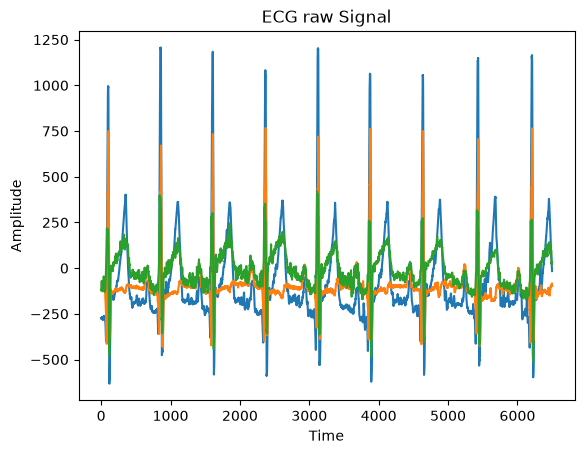

In [28]:
# plot the ECG signal

# simplified version of the code to plot the ECG signal, create a general function to plot the ECG signal
def plot_ecg_signal(ecg_data, title, x_label, y_label, time=None):
    if time is None: # condition
        plt.plot(ecg_data)
    else:
        plt.plot(time, ecg_data)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.show()

plot_ecg_signal(ECG_raw, 'ECG raw Signal', 'Time', 'Amplitude')

### Description of the plot 

The graph looks okay. The units are missing from the axes, but they are not known yet. 

The values look like raw data, because the actual values of an ECG signal are typicallly in the order of 0.5 milivolts, as explained on this page : https://fr.my-ekg.com/generalites-ecg/papier-ecg.html

The waveform looks like an ECG waveform, as shown on this page :  http://www.ecglibrary.com/norm.php

## Rescale ECG data

In order to convert the data, the following information are needed : 

The ECG recording equipment manufacturer's instructions specify:

Leads recorded  : I, II, III
Sampling frequency : 1000 Hz 
A/D converter gain : 1024 µV per unit  

For each axis, the data will be converted.
For y axis, ECG_raw will be converted in real ECG values by being divided by 1 024. 
For x axis, the variable time did not really exist in the ECGu.text file so it is created to get the time in seconds. To do so, the lenght of ECG_raw is devided by the sampling frequency. 


In [29]:
# Convert the ECG raw data to real values

# Convert y axis 
ECG_real = ECG_raw / 1024 # 1 raw unit = 1 024 µV = 1.024 mV ?

#Convert x axis
sampling_frequency = 1000
timestamps = np.arange(len(ECG_raw)) / sampling_frequency # np.arange() creates an array of evenly spaced values within a given interval, len(ECG_raw) gives the number of samples in the ECG_raw array, and dividing by the sampling frequency converts the sample indices to time in seconds.

## Plot ECG signal

Now that the values are converted, the real ECG Signal can be plot. Because the function alraedy exists, it is only needed to change the variables and the titles of the elements on the graph. 

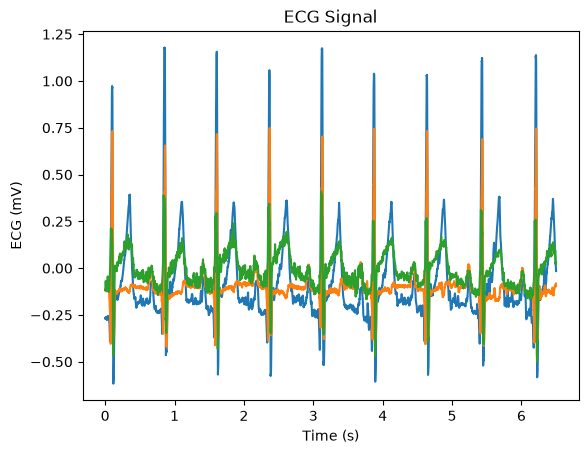

In [30]:
# plot the real ECG signal

# use function to plot the real ECG signal
plot_ecg_signal(ECG_real, 'ECG Signal', 'Time (s)', 'ECG (mV)', timestamps)

### Check the plot 

The number of timeseries and samples are correct. 
The values are consistent with the range of ECG signals  https://fr.my-ekg.com/generalites-ecg/papier-ecg.html.
The waveform is also coherent.
The signal starts at 0s and ends at 6.5 which is coherent with the number of lines and the sampling frequency. 

